# Hands-On Seaborn for Biological Data

A beginner-friendly notebook for biologists.

This notebook covers:
- Installing and importing Seaborn
- Distribution plots
- Scatter and line plots
- Categorical plots
- Pair plots
- Heatmaps
- Faceting with figure-level functions
- Styling and labeling plots
- A biology-style mini project

Each section includes short exercises.

## 1. Getting Started

If Seaborn is not installed, run one of these commands in your terminal:

```bash
pip install seaborn
```

Now import the libraries we will use.

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

sns.set_theme(style='whitegrid')
print('Seaborn imported successfully')

Seaborn imported successfully


### Exercise 1
Import Seaborn as `sns` and Matplotlib's pyplot as `plt` in the cell below.

In [37]:
# Write your answer here


## 2. Example Dataset

We will use a small tidy biological dataset.

Mental model: Seaborn works best with **long-form data**, where each row is one observation.

In [38]:
df = pd.DataFrame({
    'Gene': ['GeneA', 'GeneA', 'GeneB', 'GeneB', 'GeneC', 'GeneC', 'GeneD', 'GeneD'],
    'Condition': ['Control', 'Treatment'] * 4,
    'Expression': [5.2, 6.1, 2.1, 3.3, 7.8, 5.9, 4.4, 6.0],
    'Replicate': [1, 1, 1, 1, 1, 1, 1, 1]
})

df

,Gene,Condition,Expression,Replicate
0,GeneA,Control,5.2,1
1,GeneA,Treatment,6.1,1
2,GeneB,Control,2.1,1
3,GeneB,Treatment,3.3,1
4,GeneC,Control,7.8,1
5,GeneC,Treatment,5.9,1
6,GeneD,Control,4.4,1
7,GeneD,Treatment,6.0,1


A tidy table looks like this:
- one row = one observation
- one column = one variable

That is exactly what Seaborn likes.

### Exercise 2
Import the bacteria dataset: 

> source here: `bacteria_path = 'https://raw.githubusercontent.com/HackBio-Internship/2025_project_collection/refs/heads/main/bacteria.csv'`

In [39]:
# Write your answer here


## 3. Distribution Plots

Use these when you want to answer questions like:
- How are expression values distributed?
- Is the data skewed?
- Are there multiple peaks?

### 3.1 Histogram with `histplot()`

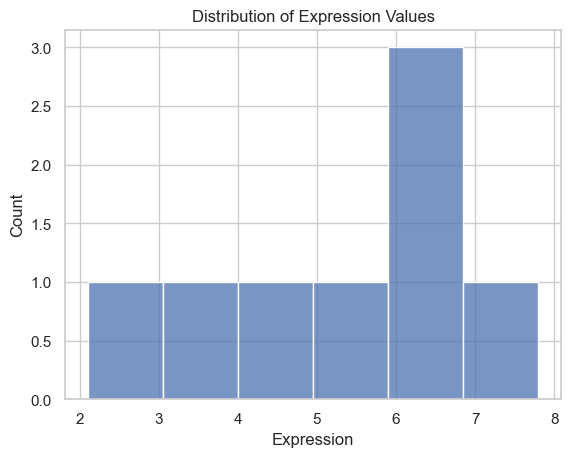

In [40]:
sns.histplot(data=df, x='Expression', bins=6)
plt.title('Distribution of Expression Values')
plt.show()

### 3.2 Smoothed density with `kdeplot()`

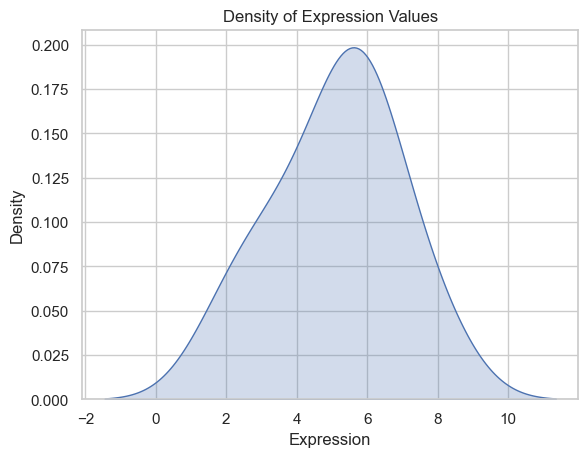

In [41]:
sns.kdeplot(data=df, x='Expression', fill=True)
plt.title('Density of Expression Values')
plt.show()

### 3.3 Compare distributions by group with `displot()`

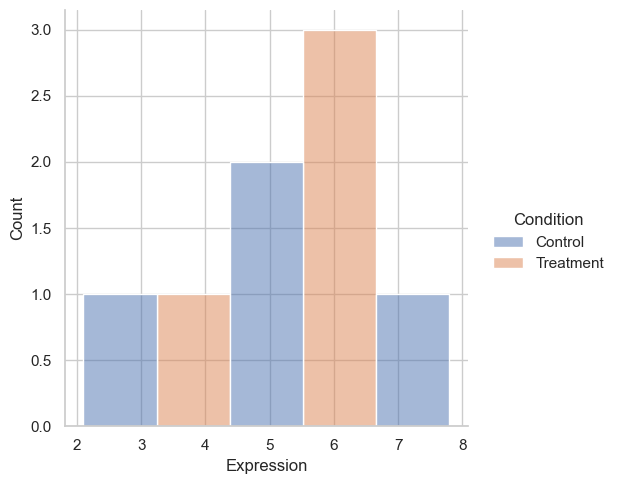

In [42]:
sns.displot(data=df, x='Expression', hue='Condition', kind='hist', bins=5)
plt.show()

`displot()` is a figure-level function. It is useful when you want to split or compare multiple distributions.

### Exercise 3
Using `bacteria_data` create:
1. A histogram of `carb_fit`
2. A KDE plot of `cipro_fit`
3. A `displot()` grouped by `Phenotype`

In [43]:
# Write your answer here


## 4. Scatter and Relationship Plots

Use these when you want to study relationships between variables.

First, let's make a slightly richer dataset.

In [44]:
growth = pd.DataFrame({
    'Time': [0, 2, 4, 6, 8, 0, 2, 4, 6, 8],
    'OD600': [0.05, 0.12, 0.24, 0.41, 0.60, 0.05, 0.15, 0.31, 0.52, 0.73],
    'Condition': ['Control'] * 5 + ['Treatment'] * 5
})

growth

,Time,OD600,Condition
0,0,0.05,Control
1,2,0.12,Control
2,4,0.24,Control
3,6,0.41,Control
4,8,0.60,Control
5,0,0.05,Treatment
6,2,0.15,Treatment
7,4,0.31,Treatment
8,6,0.52,Treatment
9,8,0.73,Treatment


### 4.1 `scatterplot()`

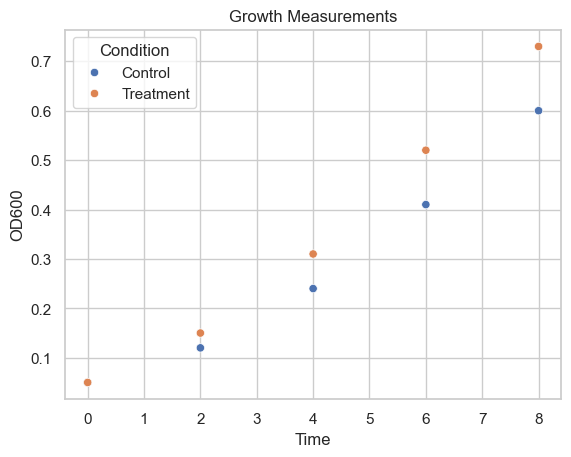

In [45]:
sns.scatterplot(data=growth, x='Time', y='OD600', hue='Condition')
plt.title('Growth Measurements')
plt.show()

### 4.2 `lineplot()`

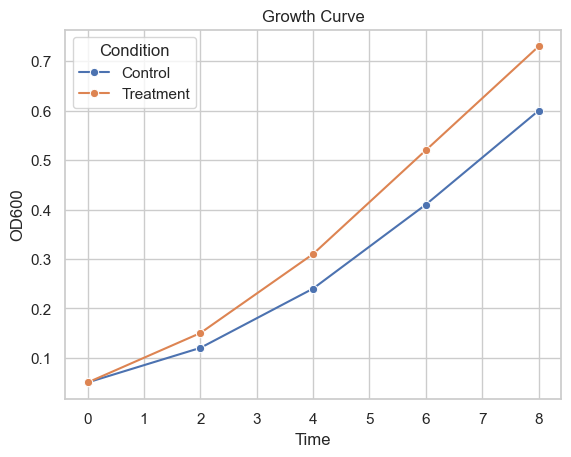

In [46]:
sns.lineplot(data=growth, x='Time', y='OD600', hue='Condition', marker='o')
plt.title('Growth Curve')
plt.show()

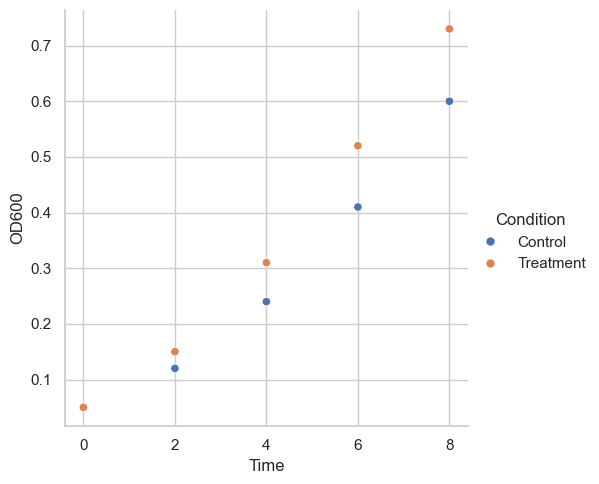

In [47]:
sns.relplot(data=growth, x='Time', y='OD600', hue='Condition', kind='scatter')
plt.show()

`relplot()` is a figure-level function and is useful when you want easy faceting later.

### Exercise 4
Using `bacteria_data`:
1. Make a scatter plot of `carb_fit` vs `pip_fit`
2. Make a line plot of `kan_fit` vs `genta_fit`
3. Color the two plots by `labels`, `phenotype` and 'Isolation Origin`

In [48]:
# Write your answer here


## 5. Categorical Plots

These are essential in biology when you compare measurements across genes, treatments, strains, or sample classes.

Let's create a dataset with replicates.

In [49]:
expr_rep = pd.DataFrame({
    'Gene': ['GeneA'] * 6 + ['GeneB'] * 6 + ['GeneC'] * 6,
    'Condition': ['Control', 'Control', 'Control', 'Treatment', 'Treatment', 'Treatment'] * 3,
    'Expression': [5.1, 5.3, 5.2, 6.0, 6.2, 6.1,
                   2.0, 2.3, 2.1, 3.0, 3.2, 3.1,
                   7.5, 7.9, 8.0, 5.7, 6.0, 6.1]
})

expr_rep.head()

,Gene,Condition,Expression
0,GeneA,Control,5.1
1,GeneA,Control,5.3
2,GeneA,Control,5.2
3,GeneA,Treatment,6.0
4,GeneA,Treatment,6.2


In [50]:
expr_rep

,Gene,Condition,Expression
0,GeneA,Control,5.1
1,GeneA,Control,5.3
2,GeneA,Control,5.2
3,GeneA,Treatment,6.0
4,GeneA,Treatment,6.2
5,GeneA,Treatment,6.1
6,GeneB,Control,2.0
7,GeneB,Control,2.3
8,GeneB,Control,2.1
9,GeneB,Treatment,3.0


### 5.1 `barplot()`

Shows a summary value, usually the mean, with error bars.

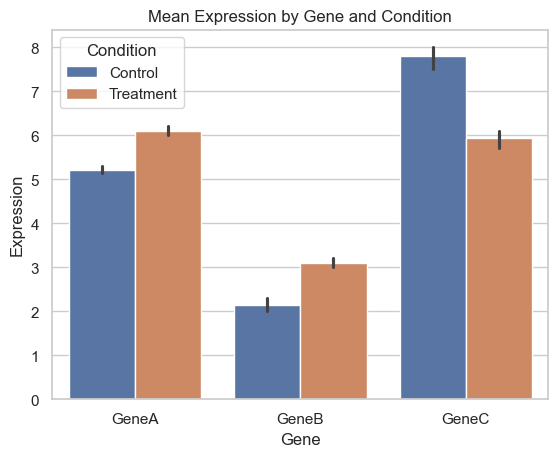

In [51]:
sns.barplot(data=expr_rep, x='Gene', y='Expression', hue='Condition')
plt.title('Mean Expression by Gene and Condition')
plt.show()

### 5.2 `boxplot()`

Shows median, quartiles, spread, and potential outliers.

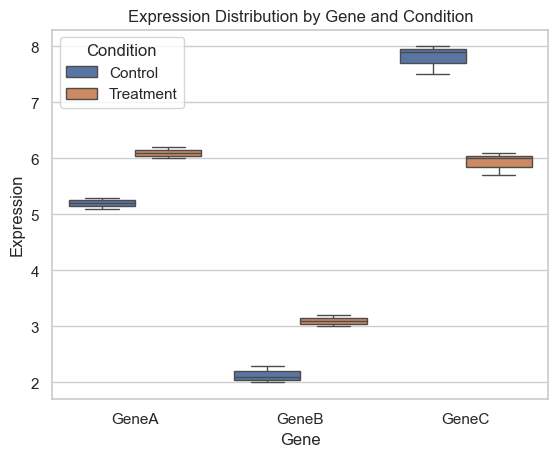

In [52]:
sns.boxplot(data=expr_rep, x='Gene', y='Expression', hue='Condition')
plt.title('Expression Distribution by Gene and Condition')
plt.show()

### 5.3 `violinplot()`

Shows the full shape of the distribution.

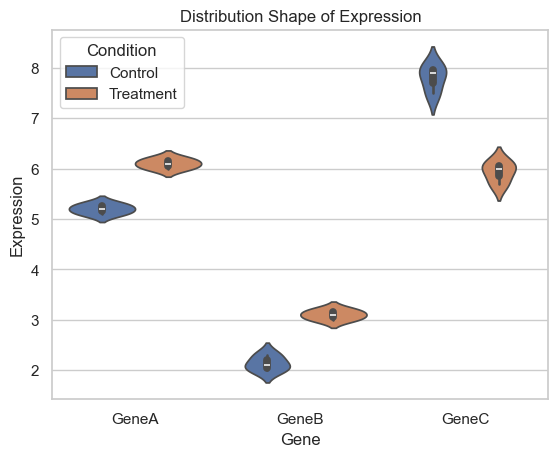

In [53]:
sns.violinplot(data=expr_rep, x='Gene', y='Expression', hue='Condition')
plt.title('Distribution Shape of Expression')
plt.show()

### 5.4 `stripplot()`

Shows raw data points.

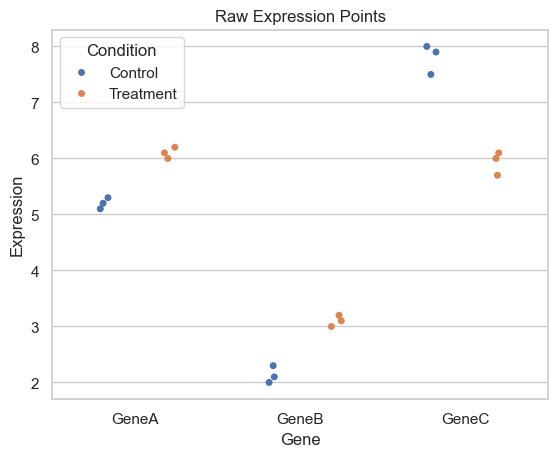

In [54]:
sns.stripplot(data=expr_rep, x='Gene', y='Expression', hue='Condition', dodge=True)
plt.title('Raw Expression Points')
plt.show()

### 5.5 `swarmplot()`

Similar to stripplot, but tries to avoid overlap.

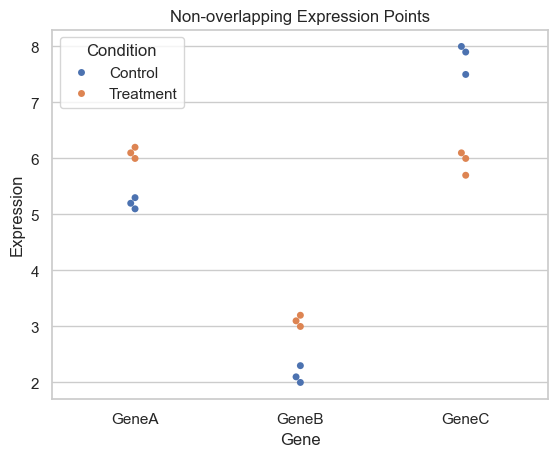

In [55]:
sns.swarmplot(data=expr_rep, x='Gene', y='Expression', hue='Condition')
plt.title('Non-overlapping Expression Points')
plt.show()

### 5.6 Overlaying summary and raw points

A very useful pattern in practice.

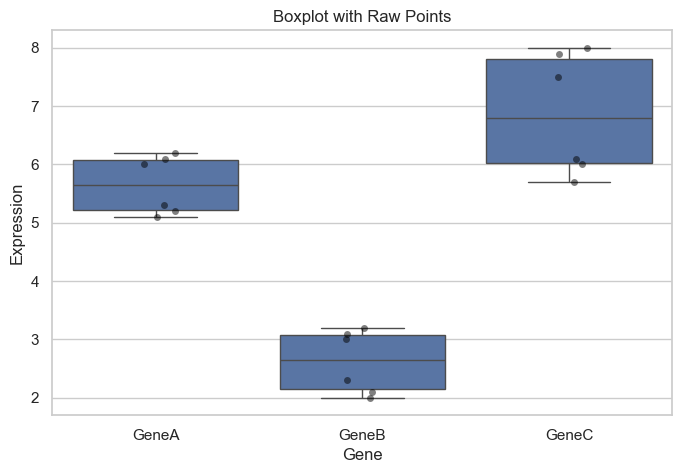

In [56]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=expr_rep, x='Gene', y='Expression')
sns.stripplot(data=expr_rep, x='Gene', y='Expression', color='black', alpha=0.5)
plt.title('Boxplot with Raw Points')
plt.show()

### Exercise 5
Using `bacteria_data`, create:
1. A bar plot grouped by `labels`
2. A box plot grouped by `Phenotypes`
3. A violin plot grouped by `Isolation Origin`
4. A strip plot or swarm plot of the raw observations

In [57]:
# Write your answer here


## 6. Pairwise Relationships with `pairplot()`

This is useful when you have multiple quantitative variables and want a quick overview.

In [58]:
cells = pd.DataFrame({
    'CellArea': [110, 115, 120, 130, 140, 150],
    'NucleusArea': [35, 38, 42, 45, 49, 55],
    'Intensity': [210, 220, 235, 240, 260, 275],
    'Condition': ['Control', 'Control', 'Control', 'Treatment', 'Treatment', 'Treatment']
})

cells

,CellArea,NucleusArea,Intensity,Condition
0,110,35,210,Control
1,115,38,220,Control
2,120,42,235,Control
3,130,45,240,Treatment
4,140,49,260,Treatment
5,150,55,275,Treatment


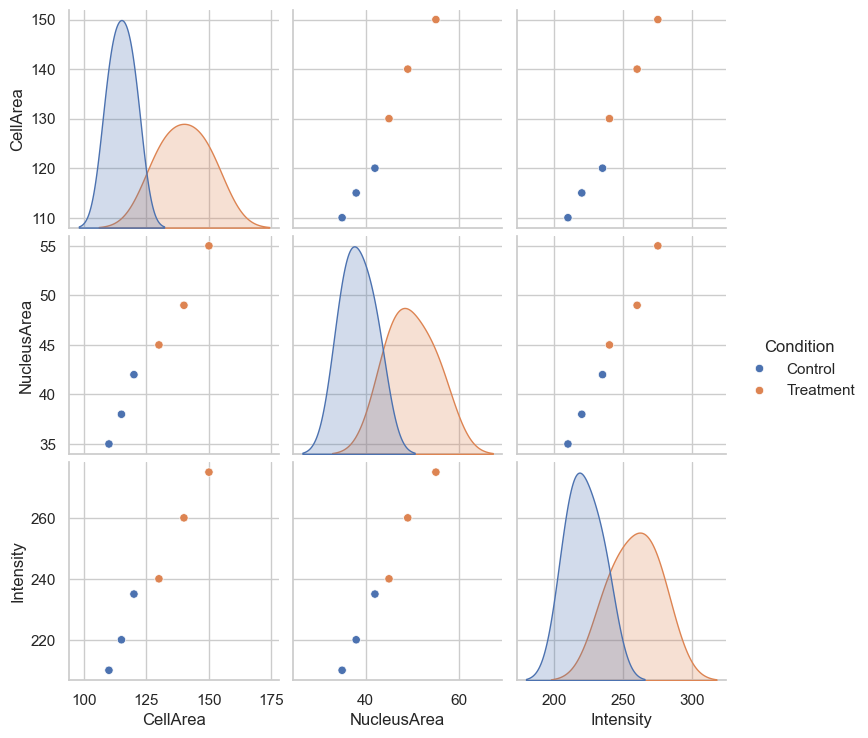

In [59]:
sns.pairplot(cells, hue='Condition')
plt.show()

### Exercise 6
Create a pair plot for `bacteria_data` colored by `labels`.

In [60]:
# Write your answer here


## 7. Heatmaps

Heatmaps are critical for biology, especially for gene expression matrices.

First pivot tidy data into a matrix.

In [61]:
heat_df = pd.DataFrame({
    'Gene': ['GeneA', 'GeneA', 'GeneB', 'GeneB', 'GeneC', 'GeneC'],
    'Condition': ['Control', 'Treatment'] * 3,
    'Expression': [5.2, 6.1, 2.1, 3.3, 7.8, 5.9]
})

matrix = heat_df.pivot(index='Gene', columns='Condition', values='Expression')
matrix

Condition,Control,Treatment
Gene,,
GeneA,5.2,6.1
GeneB,2.1,3.3
GeneC,7.8,5.9


### 7.1 Basic heatmap

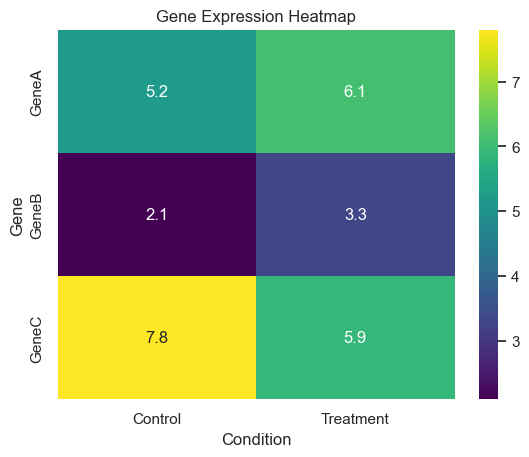

In [62]:
sns.heatmap(matrix, annot=True, cmap='viridis')
plt.title('Gene Expression Heatmap')
plt.show()

### Exercise 7
Create a heatmap from the numerical columns (all columns with a fitness value) and show the values inside the cells.

In [63]:
# Write your answer here


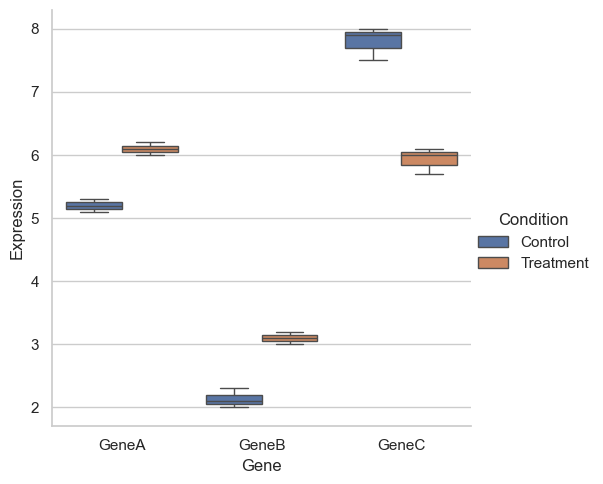

In [64]:
sns.catplot(data=expr_rep, x='Gene', y='Expression', hue='Condition', kind='box')
plt.show()

Split into one panel per condition:

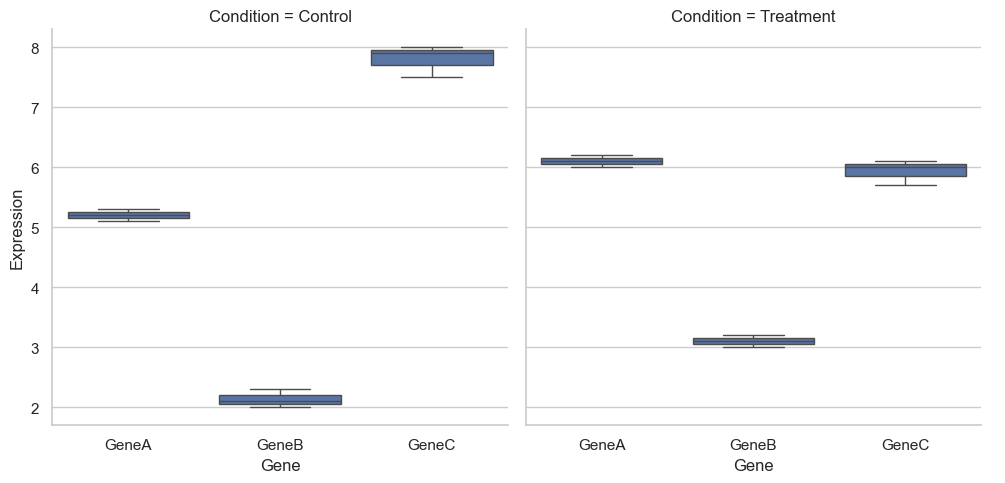

In [65]:
sns.catplot(data=expr_rep, x='Gene', y='Expression', col='Condition', kind='box')
plt.show()

### Exercise 8
Use `catplot()` to:
1. Make a box plot of `Expression` by `Gene`
2. Split the plot into columns using `Condition`

In [66]:
# Write your answer here


In [67]:
# Write your answers here


## 12. Quick Plot Guide

| Question | Plot |
|---|---|
| What is the distribution? | `histplot()`, `kdeplot()`, `displot()` |
| How do two numeric variables relate? | `scatterplot()`, `lineplot()`, `relplot()` |
| How do groups compare? | `barplot()`, `boxplot()`, `violinplot()` |
| Where are the raw observations? | `stripplot()`, `swarmplot()` |
| What do many numeric variables look like together? | `pairplot()` |
| How does a matrix look? | `heatmap()` |
| How do I split one plot into panels? | `catplot()`, `relplot()`, `displot()` |
